# CelebA-HQ AE One-Batch Debug Notebook

Minimal notebook for debugging training by overfitting a single batch and visualizing reconstructions.

In [1]:
import os
import sys
import json
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import trange
from torch.cuda.amp import autocast, GradScaler

ROOT_CANDIDATES = [os.getcwd(), os.path.abspath(os.path.join(os.getcwd(), '..'))]
REPO_ROOT = None
for candidate in ROOT_CANDIDATES:
    if os.path.isdir(os.path.join(candidate, 'src')):
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError('Could not find repo root containing src/. Run notebook from repo root or tests/.')

if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

from src.model.taxon_ae import CelebAHQTaxonAutoencoder
from src.utils.dataloader import CelebAHQLoader

/nethome/zwang910/file_storage/miniconda3/envs/dl/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Debug settings
CONFIG_PATH = os.path.join(REPO_ROOT, 'configs', 'celebahq_resnet_k3.json')
DATA_ROOT_OVERRIDE = None  # e.g. '/absolute/path/to/celeba_hq'
BATCH_SIZE = 8
NUM_WORKERS = 2
OVERFIT_STEPS = 150
NUM_VIS_IMAGES = 8
SEED = 42

torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

with open(CONFIG_PATH, 'r') as f:
    config = json.load(f)

if DATA_ROOT_OVERRIDE is not None:
    config['data']['data_root'] = DATA_ROOT_OVERRIDE

print('Config:', CONFIG_PATH)
print('Data root:', config['data']['data_root'])

Device: cuda
Config: /coc/flash10/zekun/TaxonomicWeights/configs/celebahq_resnet_k3.json
Data root: ./data/celeba_hq


In [3]:
def parse_layer_config(config_layers):
    if not config_layers:
        return None, None, None, None, None, None, None

    n_layers_list = []
    n_filters_list = []
    layer_types_list = []
    kernel_sizes_list = []
    strides_list = []
    paddings_list = []
    output_paddings_list = []

    for layer in config_layers:
        layer_types_list.append(layer.get('layer_type', 'taxonomic_conv'))
        n_layers_list.append(layer.get('n_layers', None))
        n_filters_list.append(layer.get('n_filters', None))
        kernel_sizes_list.append(layer.get('kernel_size', 3))
        strides_list.append(layer.get('stride', 1))
        paddings_list.append(layer.get('padding', None))
        output_paddings_list.append(layer.get('output_padding', 0))

    n_layers_out = n_layers_list if any(x is not None for x in n_layers_list) else None
    n_filters_out = n_filters_list if any(x is not None for x in n_filters_list) else None
    paddings_out = paddings_list if any(x is not None for x in paddings_list) else None

    return (n_layers_out, n_filters_out, layer_types_list,
            kernel_sizes_list, strides_list, paddings_out, output_paddings_list)

In [4]:
# Data loaders
loader = CelebAHQLoader(
    data_root=config['data']['data_root'],
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    image_size=config['data'].get('image_size', 256),
    val_split=config['data'].get('val_split', 0.05),
    train_subset=config['data'].get('train_subset', None),
    val_subset=config['data'].get('val_subset', None),
)
train_loader, val_loader = loader.get_loaders()
print('Train samples:', len(train_loader.dataset))
print('Val samples:', len(val_loader.dataset) if val_loader is not None else 0)

Falling back to torchvision's CelebA dataset (30k subset)
This is a temporary solution - please obtain CelebA-HQ for full quality
Train samples: 27000
Val samples: 3000


In [19]:
# Model init (same path as training script)
model_cfg = config.get('model', {})
encoder_layers = model_cfg.get('encoder_layers', [])
decoder_layers = model_cfg.get('decoder_layers', [])

(enc_n_layers, enc_n_filters, enc_layer_types, enc_kernel_sizes,
 enc_strides, enc_paddings, enc_output_paddings) = parse_layer_config(encoder_layers)
(dec_n_layers, dec_n_filters, dec_layer_types, dec_kernel_sizes,
 dec_strides, dec_paddings, dec_output_paddings) = parse_layer_config(decoder_layers)

model = CelebAHQTaxonAutoencoder(
    latent_dim=model_cfg.get('latent_dim', 256),
    temperature=model_cfg.get('temperature', 1.0),
    encoder_kernel_sizes=enc_kernel_sizes,
    decoder_kernel_sizes=dec_kernel_sizes,
    encoder_strides=enc_strides,
    decoder_strides=dec_strides,
    encoder_n_layers=enc_n_layers,
    decoder_n_layers=dec_n_layers,
    encoder_n_filters=enc_n_filters,
    decoder_n_filters=dec_n_filters,
    encoder_layer_types=enc_layer_types,
    decoder_layer_types=dec_layer_types,
    decoder_paddings=dec_paddings,
    decoder_output_paddings=dec_output_paddings,
    use_maxpool=model_cfg.get('use_maxpool', True),
    output_activation=model_cfg.get('output_activation', 'sigmoid'),
).to(DEVICE)

print('Model params:', sum(p.numel() for p in model.parameters()))
model

Model params: 640045


CelebAHQTaxonAutoencoder(
  (encoder): CelebAHQTaxonEncoder(
    (conv_layers): ModuleList(
      (0): TaxonConv(
        (convs): ModuleList(
          (0): ResidualConvBlock(
            (block): Sequential(
              (0): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (1): Conv2d(3, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (2): ReLU(inplace=True)
              (3): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (4): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            )
            (skip): Conv2d(3, 1, kernel_size=(1, 1), stride=(2, 2), bias=False)
          )
          (1): ResidualConvBlock(
            (block): Sequential(
              (0): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (1): Conv2d(3, 2, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)


In [20]:
def unpack_model_output(result):
    if isinstance(result, tuple) and len(result) == 3:
        return result
    if isinstance(result, tuple):
        return result[0], 0.0, 0.0
    return result, 0.0, 0.0

def show_recons(images, recons, title, n=8):
    n = min(n, images.size(0))
    images = images.detach().cpu()
    recons = recons.detach().cpu()
    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        axes[0, i].imshow(images[i].permute(1, 2, 0).clamp(0, 1))
        axes[0, i].axis('off')
        axes[1, i].imshow(recons[i].permute(1, 2, 0).clamp(0, 1))
        axes[1, i].axis('off')
    axes[0, 0].set_title('Original')
    axes[1, 0].set_title('Decoded')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

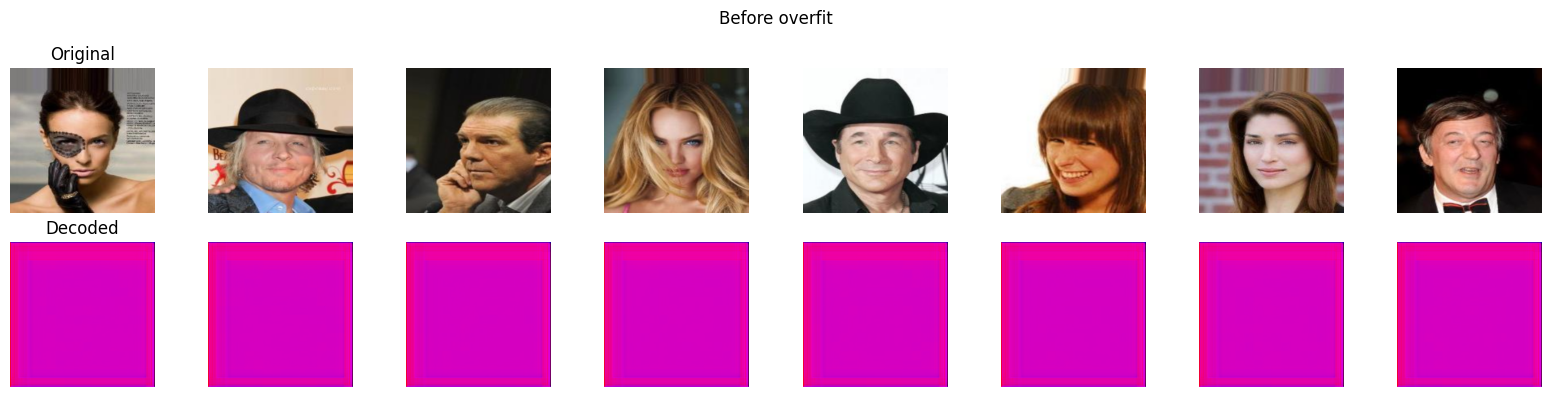

In [21]:
# First train batch (fixed)
train_images, _ = next(iter(train_loader))
train_images = train_images.to(DEVICE)

model.eval()
with torch.no_grad():
    pre_recons, _, _ = unpack_model_output(model(train_images))

show_recons(train_images, pre_recons, title='Before overfit', n=NUM_VIS_IMAGES)

In [25]:
# Overfit one batch
# criterion = nn.L1Loss()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config['training'].get('learning_rate', 1e-4))
entropy_weight = config['training'].get('entropy_weight', 0.0)
batch_kl_weight = config['training'].get('batch_kl_weight', 0.0)

use_amp = DEVICE.type == 'cuda'
scaler = GradScaler(enabled=use_amp)
loss_history = []

model.train()
for step in trange(1000, desc='Overfit one batch'):
    optimizer.zero_grad(set_to_none=True)
    with autocast(enabled=use_amp):
        recons, entropy_reg, batch_kl_reg = unpack_model_output(model(train_images))
        recon_loss = criterion(recons, train_images)
        loss = recon_loss + entropy_weight * entropy_reg + batch_kl_weight * batch_kl_reg

    if not torch.isfinite(loss):
        raise RuntimeError(f'Non-finite loss at step {step}: {loss.item()}')

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(optimizer)
    scaler.update()

    loss_history.append(float(loss.detach().cpu()))

print('Final overfit loss:', loss_history[-1])

/tmp/ipykernel_1661789/3300042129.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)
Overfit one batch:   0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_1661789/3300042129.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Overfit one batch: 100%|██████████| 1000/1000 [03:20<00:00,  4.98it/s]

Final overfit loss: 0.03636542707681656


Train fixed-batch L1 after overfit: 0.11322502791881561
Eval first-batch L1 after overfit: 0.09831784665584564


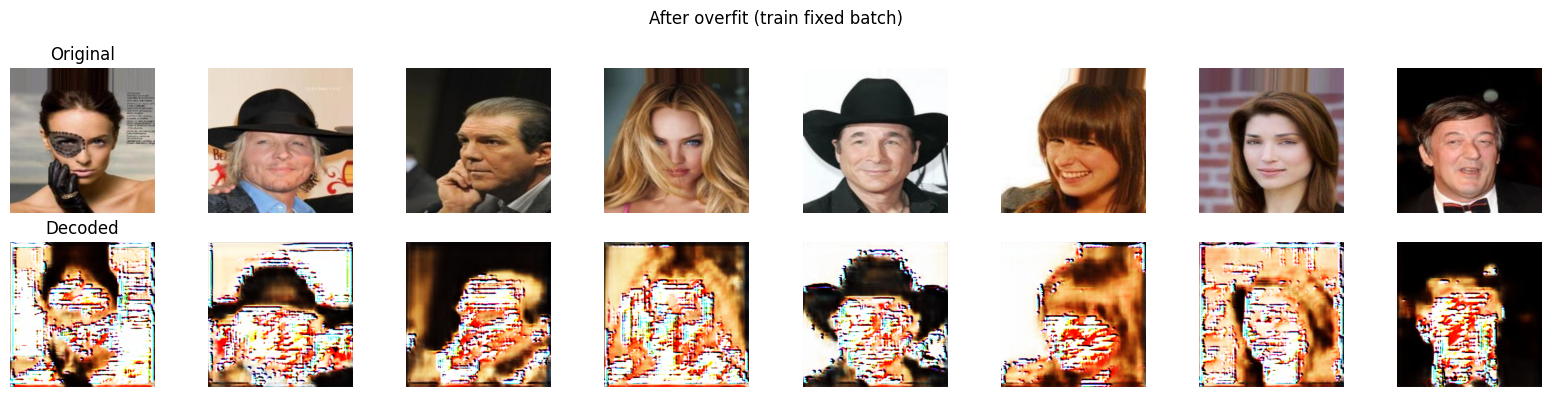

In [26]:
# Evaluation: first val batch (or train batch if val unavailable)
eval_loader = val_loader if val_loader is not None else train_loader
eval_images, _ = next(iter(eval_loader))
eval_images = eval_images.to(DEVICE)

model.eval()
with torch.no_grad():
    post_recons_train, _, _ = unpack_model_output(model(train_images))
    eval_recons, _, _ = unpack_model_output(model(eval_images))

train_overfit_l1 = criterion(post_recons_train, train_images).item()
eval_l1 = criterion(eval_recons, eval_images).item()
print('Train fixed-batch L1 after overfit:', train_overfit_l1)
print('Eval first-batch L1 after overfit:', eval_l1)

show_recons(train_images, post_recons_train, title='After overfit (train fixed batch)', n=NUM_VIS_IMAGES)

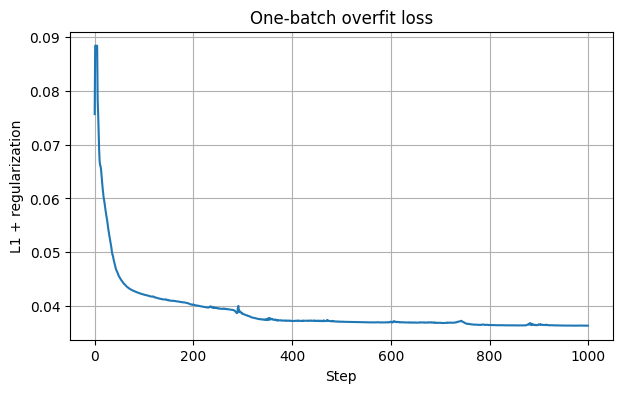

In [27]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.title('One-batch overfit loss')
plt.xlabel('Step')
plt.ylabel('L1 + regularization')
plt.grid(True)
plt.show()